# NGSO SLS — Intent Analytics (live Spacetime / fss01-demo)

What the solver actually *decided*, derived from installed intents: gateway load, route
structure, contact-plan Gantt, OISL mesh, and predicted-vs-actual validation with the
node→platform id join done properly (via `RK_CONTAINS`).

**Data source:** live raw Store on `localhost:9999` (see `tools/sandbox_live_setup.sh` for the
port-forward) with automatic fallback to the textproto dump at `/workspace/fss01-demo-dump/`.


In [1]:
# === Setup & load (live store, dump fallback) ===
# Portable: repo root is resolved relative to this notebook, so this runs unmodified in the
# sandbox, on a laptop clone, or in Colab. Override the data source with env vars:
#   SLS_STORE_TARGET  (default localhost:9999 — needs `kubectl port-forward svc/storage 9999`)
#   SLS_DUMP_DIR      (default <repo>/../fss01-demo-dump, then /workspace/fss01-demo-dump)
import os, sys, collections, datetime, pathlib
_REPO = pathlib.Path.cwd().resolve()
while _REPO != _REPO.parent and not (_REPO / "ngso_sls").is_dir():
    _REPO = _REPO.parent
if not (_REPO / "ngso_sls").is_dir():                    # cwd outside a checkout:
    _anchor = pathlib.Path("/workspace/spacetime-sls")    # sandbox/host mount anchor
    if (_anchor / "ngso_sls").is_dir():
        _REPO = _anchor
if not (_REPO / "ngso_sls").is_dir():                    # bare runtime (Colab): clone + install
    import subprocess
    _url = "https://github.com/luca-aalyria/spacetime-sls.git"
    try:                                                  # private repo: Colab secret GITHUB_TOKEN
        from google.colab import userdata
        _tok = userdata.get("GITHUB_TOKEN")
        if _tok:
            _url = _url.replace("https://", f"https://{_tok}@")
    except Exception:
        pass
    subprocess.run(["git", "clone", "-q", _url], check=True)
    _REPO = (pathlib.Path.cwd() / "spacetime-sls").resolve()
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", str(_REPO)], check=False)
for p in (str(_REPO), str(_REPO / "vendor" / "spacetime_api_stubs")):
    if p not in sys.path:
        sys.path.insert(0, p)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET = os.environ.get("SLS_STORE_TARGET", "localhost:9999")
DUMP_DIR = os.environ.get("SLS_DUMP_DIR") or next(
    (str(d) for d in (_REPO.parent / "fss01-demo-dump",
                      pathlib.Path("/workspace/fss01-demo-dump")) if d.is_dir()),
    str(_REPO.parent / "fss01-demo-dump"))
SOURCE = None
try:
    from ngso_sls.spacetime.client import StorageEntityStore
    _store = StorageEntityStore(TARGET)
    raw_intents = _store.list_intents()                     # resources.Intent protos
    plat_views  = [e for e in _store.list_entities() if e.kind == 11]   # ek_platform
    rels        = _store.list_relationships()
    SOURCE = f"live {TARGET}"
except Exception as exc:
    print(f"live store unavailable -> loading dump\n  cause: {exc}\n"
          "  (live needs a kubectl port-forward to svc/storage:9999 running on THIS machine"
          " — sandbox/host each need their own; see tools/sandbox_live_setup.sh)")
    import glob
    from google.protobuf import text_format
    from ngso_sls.spacetime import _deps
    from ngso_sls.spacetime.client import _NmtsEntityView
    def _load(pattern):
        out = []
        for path in sorted(glob.glob(f"{DUMP_DIR}/{pattern}")):
            box = _deps.storage_pb2.TxtpbEntities()
            with open(path) as f:
                text_format.Parse(f.read(), box)
            out.extend(box.entity)
        return out
    raw_intents = [e.intent for e in _load("intents/*.txtpb")]
    plat_views  = [_NmtsEntityView(e.nmts_entity) for e in _load("nmts/entities_ek_platform.txtpb")]
    rels        = [e.nmts_relationship for e in _load("nmts/relationships_rk_contains.txtpb")]
    SOURCE = f"dump {DUMP_DIR}"

print(f"source: {SOURCE}")
print(f"{len(raw_intents)} intents, {len(plat_views)} platforms, {len(rels)} relationships")


source: live localhost:9999
2609 intents, 377 platforms, 29330 relationships


In [2]:
# === Id joins & platform metadata ===
# RK_CONTAINS(platform -> network-node) is the authoritative node->platform join
# (this is the mapping notebook 05's first validation pass was missing).
RK_CONTAINS = 4
node2plat = {r.z: r.a for r in rels
             if int(r.kind) == RK_CONTAINS and str(r.z).endswith("-network-node")}

plat = {}
for v in plat_views:
    p = v.platform
    name, cat = str(p.name), str(p.category_tag)
    entry = p.motion.entry[0] if len(p.motion.entry) else None
    arm = entry.WhichOneof("type") if entry is not None and entry.DESCRIPTOR.oneofs else None
    row = {"name": name, "category": cat}
    if arm == "geodetic_wgs84":
        row.update(lat=entry.geodetic_wgs84.latitude_deg, lon=entry.geodetic_wgs84.longitude_deg)
    if cat == "LEO" and "." in name:                     # satellite-N-1200.P.S -> plane/slot
        try:
            _alt, plane, slot = name.rsplit("-", 1)[1].split(".")
            row.update(plane=int(plane), slot=int(slot))
        except ValueError:
            pass
    plat[v.id] = row

def plat_of(node_id):
    return node2plat.get(node_id, node_id)

def short(pid):                                          # 'satellite-55-platform' -> 'sat-55'
    return (pid.replace("-platform", "").replace("satellite-", "sat-")
               .replace("gateway-", "gw-").replace("user-terminal-", "ut-")
               .replace("-network-node", ""))

n_sats = sum(1 for r in plat.values() if r["category"] == "LEO")
print(f"node->platform joins: {len(node2plat)} | platforms: {n_sats} LEO, "
      f"{sum(1 for r in plat.values() if r['category']=='Gateway')} gateways, "
      f"{sum(1 for r in plat.values() if r['category']=='UserTerminal')} UTs")


node->platform joins: 377 | platforms: 150 LEO, 24 gateways, 202 UTs


state  INSTALLED
type            
cell         206
link        1022
modem        945
route        436


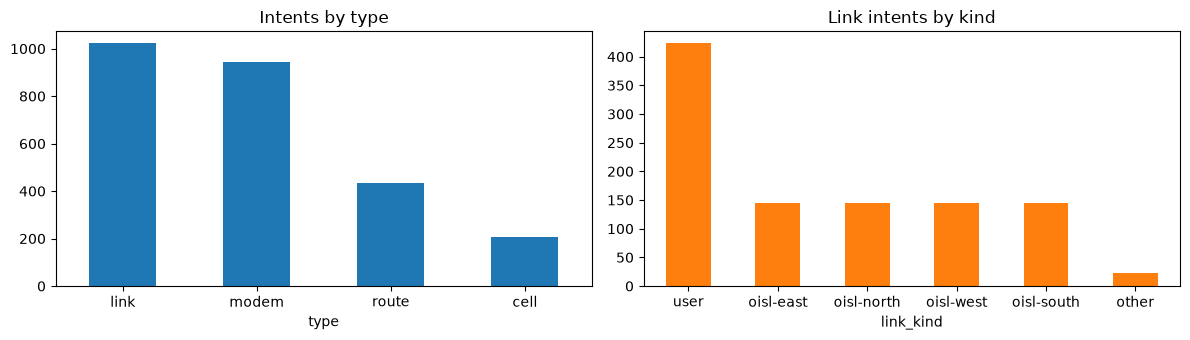

In [3]:
# === Intent DataFrame ===
def state_name(i):
    s = getattr(i, "state", 0)
    return i.DESCRIPTOR.fields_by_name["state"].enum_type.values_by_number[int(s)].name

def link_kind(i):
    mod = str(i.link.directional_link.radio_configuration.tx_radio.modulator_id)
    if "oisl" in mod:  return "oisl-" + mod.split("oisl-")[1].split("-")[0]
    if "user" in mod or "user-terminal" in mod:  return "user"
    if "feeder" in mod or "gateway" in mod:      return "feeder"
    return "other"

rows = []
for i in raw_intents:
    arm = i.WhichOneof("value")
    if arm is None:
        continue
    rows.append({
        "type": arm, "state": state_name(i),
        "enact_s": i.time_to_enact.seconds or None,
        "withdraw_s": (i.time_to_withdraw.unix_time_usec / 1e6) or None,   # DateTime, not Timestamp
        "link_kind": link_kind(i) if arm == "link" else None,
        "n_hops": len(i.route.path_segments) if arm == "route" else None,
    })
idf = pd.DataFrame(rows)
print(idf.groupby(["type", "state"]).size().unstack(fill_value=0))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
idf["type"].value_counts().plot.bar(ax=ax[0], title="Intents by type", rot=0)
idf[idf.type == "link"]["link_kind"].value_counts().plot.bar(
    ax=ax[1], title="Link intents by kind", rot=0, color="tab:orange")
plt.tight_layout(); plt.show()


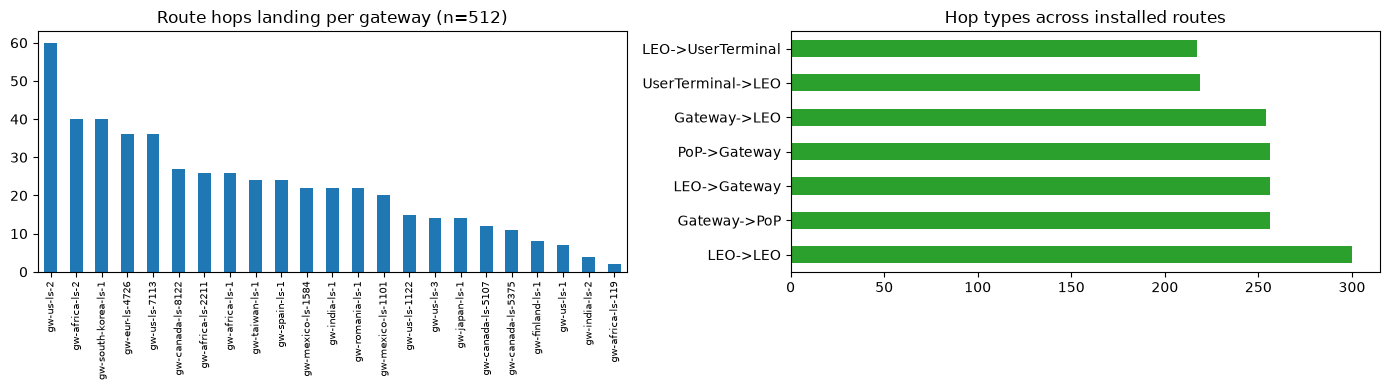

gateway load: min=2, median=22, max=60 (imbalance max/min = 30.0x)


In [4]:
# === Gateway load (routes terminating per gateway + feeder links) ===
gw_route_load = collections.Counter()
hop_types = collections.Counter()
for i in raw_intents:
    if i.WhichOneof("value") != "route":
        continue
    for seg in i.route.path_segments:
        s, d = plat_of(seg.src_network_node_id), plat_of(seg.dst_network_node_id)
        sc = plat.get(s, {}).get("category", "PoP")
        dc = plat.get(d, {}).get("category", "PoP")
        hop_types[f"{sc}->{dc}"] += 1
        if dc == "Gateway":
            gw_route_load[short(d)] += 1

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
load = pd.Series(gw_route_load).sort_values(ascending=False)
load.plot.bar(ax=ax[0], title=f"Route hops landing per gateway (n={load.sum()})")
ax[0].tick_params(axis='x', labelsize=7)
pd.Series(hop_types).sort_values(ascending=False).plot.barh(
    ax=ax[1], title="Hop types across installed routes", color="tab:green")
plt.tight_layout(); plt.show()
print(f"gateway load: min={load.min()}, median={load.median():.0f}, max={load.max()} "
      f"(imbalance max/min = {load.max()/max(load.min(),1):.1f}x)")


227 user-link (ut,sat,enact) records over 199 UTs; UTs with >=2 segments (handovers visible): 26


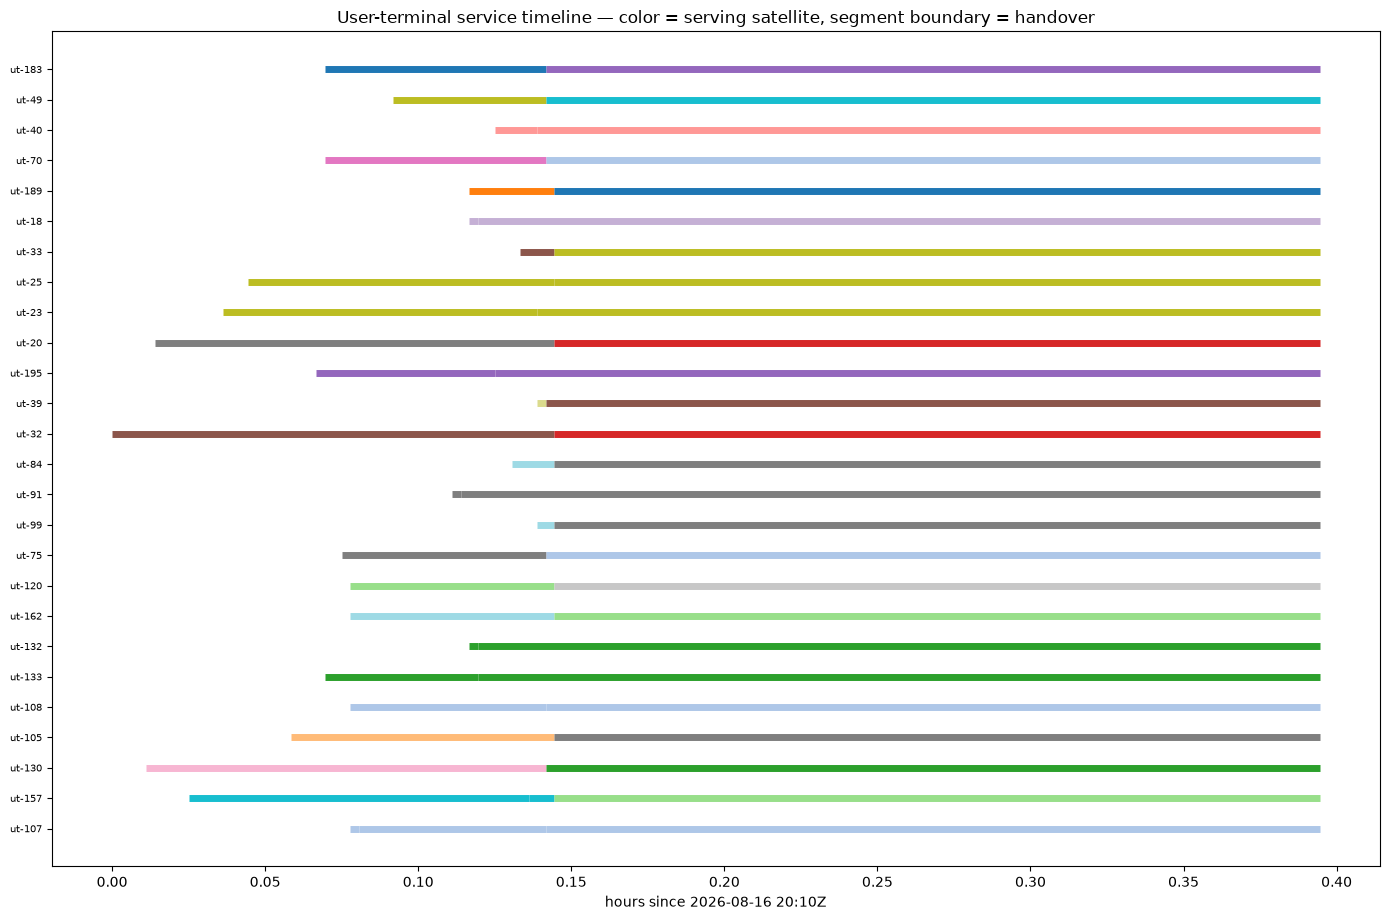

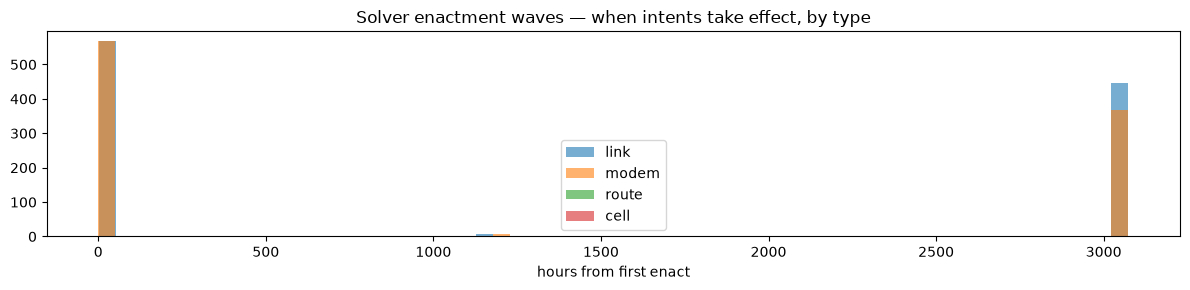

In [5]:
# === User-access contact plan (handover timeline) ===
# Link intents here are OPEN-ENDED (withdraw unset): each user link runs from its enact time
# until the solver replaces it. Reconstructing per-UT service segments: a UT's link ends when
# its NEXT link enacts -> the segment boundaries ARE the handover schedule.
def endpoints(i):
    dl = i.link.directional_link
    a = str(dl.platform_id)
    b = str(dl.rx_platforms[0].platform_id) if len(dl.rx_platforms) else None
    return a, b

user_links = []
for i in raw_intents:
    if i.WhichOneof("value") != "link":
        continue
    a, b = endpoints(i)
    if b is None or not i.time_to_enact.seconds:
        continue
    ut = a if a.startswith("user-terminal") else (b if b.startswith("user-terminal") else None)
    sat = a if a.startswith("satellite") else (b if b.startswith("satellite") else None)
    if ut and sat:
        user_links.append({"ut": short(ut), "sat": short(sat), "t": i.time_to_enact.seconds})
ul = pd.DataFrame(user_links).drop_duplicates()      # fwd+rtn arrive as two intents
per_ut = ul.groupby("ut").size().sort_values(ascending=False)
print(f"{len(ul)} user-link (ut,sat,enact) records over {ul.ut.nunique()} UTs; "
      f"UTs with >=2 segments (handovers visible): {(per_ut>=2).sum()}")

show = per_ut[per_ut >= 2].index[:30]
if len(show):
    t_ref = ul[ul.ut.isin(show)]["t"].min()
    sats = sorted(ul["sat"].unique())
    cmap = plt.get_cmap("tab20", len(sats))
    fig, ax = plt.subplots(figsize=(14, 0.3 * len(show) + 1.5))
    t_end = ul["t"].max() + 900
    for y, ut in enumerate(show):
        seq = ul[ul.ut == ut].sort_values("t")
        ts = list(seq["t"]) + [t_end]
        for k, (_, r) in enumerate(seq.iterrows()):
            ax.hlines(y, (ts[k]-t_ref)/3600, (ts[k+1]-t_ref)/3600, lw=5,
                      color=cmap(sats.index(r.sat)))
    ax.set_yticks(range(len(show))); ax.set_yticklabels(show, fontsize=7)
    ax.set_xlabel(f"hours since {datetime.datetime.fromtimestamp(t_ref, datetime.timezone.utc):%Y-%m-%d %H:%M}Z")
    ax.set_title("User-terminal service timeline — color = serving satellite, "
                 "segment boundary = handover")
    plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12, 3))
for arm in idf["type"].unique():
    ts = idf[(idf.type == arm) & idf.enact_s.notna()]["enact_s"]
    if len(ts):
        ax.hist((ts - idf.enact_s.min())/3600, bins=60, alpha=0.6, label=arm)
ax.set_xlabel("hours from first enact"); ax.legend()
ax.set_title("Solver enactment waves — when intents take effect, by type")
plt.tight_layout(); plt.show()


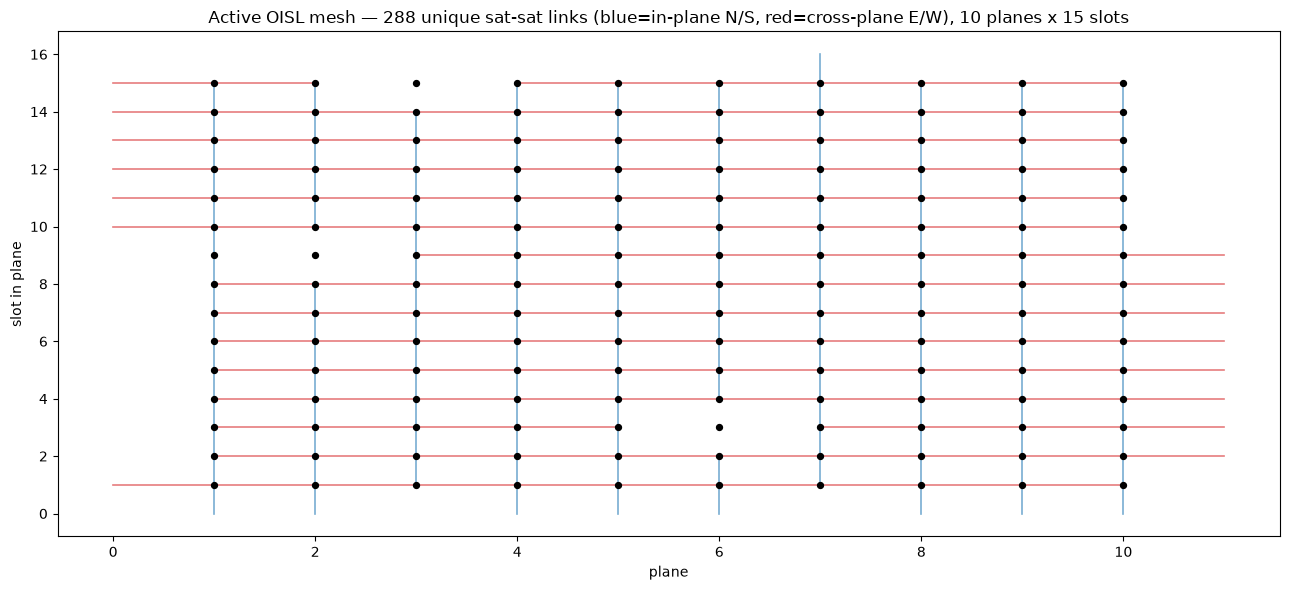

in-plane links: 144, cross-plane: 144


In [6]:
# === OISL mesh on the (plane, slot) lattice ===
pos = {pid: (r["plane"], r["slot"]) for pid, r in plat.items() if "plane" in r}
edges = collections.Counter()
for i in raw_intents:
    if i.WhichOneof("value") != "link" or not str(link_kind(i)).startswith("oisl"):
        continue
    dl = i.link.directional_link
    a = str(dl.platform_id)
    b = str(dl.rx_platforms[0].platform_id) if len(dl.rx_platforms) else None
    if b and a in pos and b in pos:
        edges[tuple(sorted((a, b)))] += 1

fig, ax = plt.subplots(figsize=(13, 6))
for (a, b), n in edges.items():
    (p1, s1), (p2, s2) = pos[a], pos[b]
    if abs(p1 - p2) > 5:   p2 += 10 if p1 > p2 else -10       # wrap plane seam
    if abs(s1 - s2) > 7:   s2 += 15 if s1 > s2 else -15       # wrap slot seam
    intra = (p1 == p2)
    ax.plot([p1, p2], [s1, s2], lw=1.2, alpha=0.6,
            color="tab:blue" if intra else "tab:red")
xs = [p for (p, s) in pos.values()]; ys = [s for (p, s) in pos.values()]
ax.scatter(xs, ys, s=18, c="k", zorder=3)
ax.set_xlabel("plane"); ax.set_ylabel("slot in plane")
ax.set_title(f"Active OISL mesh — {len(edges)} unique sat-sat links "
             f"(blue=in-plane N/S, red=cross-plane E/W), 10 planes x 15 slots")
plt.tight_layout(); plt.show()
in_plane = sum(1 for (a, b) in edges if pos[a][0] == pos[b][0])
print(f"in-plane links: {in_plane}, cross-plane: {len(edges) - in_plane}")


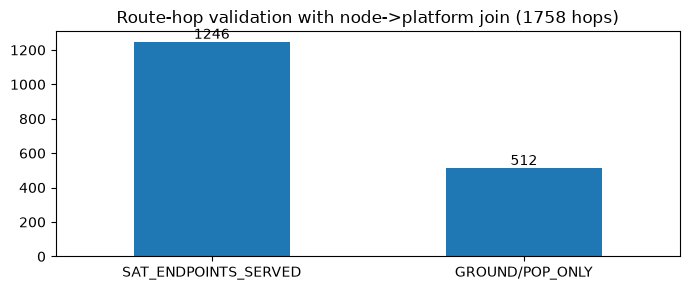

hops with all satellite endpoints served by the SLS pull: 100.0% (vs 0% in the naive id comparison)


In [7]:
# === Predicted vs actual — validation with the PROPER node->platform join ===
# Fix for notebook 05 cell 11: hop endpoints are network-node ids; join to platforms via
# RK_CONTAINS, classify ground endpoints as GROUND (not 'skipped'), and check sat endpoints
# against the set of Keplerian-served satellites.
served_sats = {pid for pid, r in plat.items() if r["category"] == "LEO"}

def classify(node_id):
    p = plat_of(node_id)
    cat = plat.get(p, {}).get("category")
    if cat == "LEO":
        return "SAT_SERVED" if p in served_sats else "SAT_UNSERVED"
    return "GROUND" if cat in ("Gateway", "UserTerminal") else "OTHER(PoP)"

verdicts = collections.Counter()
hops = 0
for i in raw_intents:
    if i.WhichOneof("value") != "route":
        continue
    for seg in i.route.path_segments:
        hops += 1
        cs, cd = classify(seg.src_network_node_id), classify(seg.dst_network_node_id)
        if "SAT_UNSERVED" in (cs, cd):
            verdicts["UNSERVED_SAT_ENDPOINT"] += 1
        elif cs.startswith("SAT") or cd.startswith("SAT"):
            verdicts["SAT_ENDPOINTS_SERVED"] += 1
        else:
            verdicts["GROUND/POP_ONLY"] += 1

vs = pd.Series(verdicts)
ax = vs.plot.bar(figsize=(7, 3), rot=0,
                 title=f"Route-hop validation with node->platform join ({hops} hops)")
for p_, v in zip(ax.patches, vs):
    ax.annotate(str(v), (p_.get_x() + p_.get_width()/2, v), ha="center", va="bottom")
plt.tight_layout(); plt.show()
cov = verdicts["SAT_ENDPOINTS_SERVED"] / max(1, hops - verdicts["GROUND/POP_ONLY"])
print(f"hops with all satellite endpoints served by the SLS pull: {cov:.1%} "
      f"(vs 0% in the naive id comparison)")


**Reading the results**
- *Gateway load* exposes the solver's feeder-balancing; a high max/min ratio means geography
  (or weather/regulatory masks) is concentrating traffic.
- *Contact-plan Gantt* is the solver's actual schedule — the SLS equivalent is the visibility
  interval family (Slice A `in-view intervals`), so these two charts are directly comparable.
- *OISL mesh* should show a clean 4-neighbor lattice; missing edges = links the solver chose
  not to (or could not) install.
- *Validation* now joins node→platform via `RK_CONTAINS`; the remaining gap to a full
  predicted-vs-actual is checking each contact window against SLS-computed visibility
  (Slice A intervals) — queued as the next increment.
